# Boston Housing Dataset - Exploratory Data Analysis

## Project Overview

This project performs an exploratory data analysis (EDA) on the Boston Housing Dataset.

The main objectives are:

- Understand the dataset
- Explore feature distributions
- Handle missing values
- Analyze feature correlations
- Visualize important relationships
- Draw meaningful insights

### Step 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Housing.csv')

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])
print("-" * 40)

#print(df.info())

for col in df.columns:
    unique_count = df[col].nunique()
    print(f"Column: {col:<10} | Dtype: {str(df[col].dtype):<8} | Unique Values: {unique_count}")

Rows : 509
Columns : 14
----------------------------------------
Column: CRIM       | Dtype: float64  | Unique Values: 503
Column: ZN         | Dtype: float64  | Unique Values: 26
Column: INDUS      | Dtype: float64  | Unique Values: 76
Column: CHAS       | Dtype: int64    | Unique Values: 2
Column: NOX        | Dtype: float64  | Unique Values: 81
Column: RM         | Dtype: float64  | Unique Values: 446
Column: AGE        | Dtype: float64  | Unique Values: 354
Column: DIS        | Dtype: float64  | Unique Values: 411
Column: RAD        | Dtype: float64  | Unique Values: 9
Column: TAX        | Dtype: int64    | Unique Values: 66
Column: PTRATIO    | Dtype: float64  | Unique Values: 46
Column: B          | Dtype: float64  | Unique Values: 356
Column: LSTAT      | Dtype: float64  | Unique Values: 453
Column: MEDV       | Dtype: float64  | Unique Values: 228


### Data Types

Although the output of the `.info()` method shows that all columns are numeric (`float64` or `int64`), analyzing the number of unique values reveals that some features are actually **categorical/qualitative** in nature and have been numerically encoded beforehand.

#### Encoded Categorical / Ordinal Variables:

- **`CHAS`** (Proximity to Charles River):  
  Contains only **2 unique values** (0 and 1).  
  This is a binary qualitative variable (Yes/No) that has been encoded for use in regression models.

- **`RAD`** (Index of accessibility to radial highways):  
  Has a limited number of distinct values. This feature behaves more like an **ordinal** (ranked) or categorical variable rather than a continuous numeric one.

#### True Numeric / Continuous Variables:

- The remaining **12 columns** in the dataset (such as crime rate `CRIM`, number of rooms `RM`, `% lower status population` `LSTAT`, and the target variable `MEDV`) have many unique values and exhibit fully continuous numeric behavior.

In [2]:
descriptive_stats = df.describe().T
descriptive_stats['variance'] = df.var(numeric_only=True)

descriptive_stats = descriptive_stats[['count', 'mean', '50%', 'variance', 'min', '25%', '75%', 'max']]
descriptive_stats.rename(columns={'50%': 'median'}, inplace=True)
descriptive_stats

,count,mean,median,variance,min,25%,75%,max
CRIM,509.0,3.707516,0.26169,76.249376,0.00632,0.08221,3.69311,88.9762
ZN,509.0,11.296660,0.00000,541.482686,0.00000,0.00000,12.50000,100.0000
INDUS,506.0,11.198281,9.69000,47.014510,0.46000,5.19000,18.10000,27.7400
CHAS,509.0,0.068762,0.00000,0.064160,0.00000,0.00000,0.00000,1.0000
NOX,507.0,0.555216,0.53800,0.013371,0.38500,0.44900,0.62400,0.8710
RM,509.0,6.279845,6.20200,0.494841,3.56100,5.88000,6.61900,8.7800
AGE,508.0,68.579134,77.15000,790.438814,2.90000,45.07500,94.10000,100.0000
DIS,509.0,3.787705,3.18270,4.417782,1.12960,2.10070,5.11800,12.1265
RAD,508.0,9.610236,5.00000,76.301433,1.00000,4.00000,24.00000,24.0000
TAX,509.0,409.216110,330.00000,28498.220921,187.00000,279.00000,666.00000,711.0000


### 1. Target Variable Analysis (`MEDV` - Median House Prices)

* **Mean and Median:** The average house price is approximately **22.57**, while the median (2nd quartile) is **21.40** (in thousands of dollars). The closeness of these two values suggests that the overall price distribution is relatively symmetric.
* **Range:** House prices range from a minimum of **5** to a maximum of **50**. The price cap at 50 likely indicates the presence of luxury homes or censored values in the dataset.

### 2. Key Independent Feature Analysis

* **Number of Rooms (`RM`):** Houses have an average of **6.28** rooms. The minimum is 3.56 and the maximum is 8.78, indicating that most houses fall within a typical residential range.
* **Age of Buildings (`AGE`):** The average age of buildings is quite high at approximately **68.5** years. The third quartile (94.1 years) shows that more than 25% of the houses are very old, close to 100 years old.
* **Socioeconomic Status of Neighborhood (`LSTAT`):** The average percentage of lower-status population in the neighborhoods is **12.6%**. However, this feature has high variance, ranging from **1.7%** to **37.9%**, highlighting significant socioeconomic differences across neighborhoods.

### 3. Dispersion Analysis (Variance)

* **Highest Dispersion:** The `TAX` variable (property tax rate) has the highest variance at **28,436.8**, showing the greatest numerical diversity in the dataset.
* **Lowest Dispersion:** The `NOX` variable (nitrogen oxide concentration) has the lowest variance at **0.01**, indicating that its values are very close to each other with minimal variation.

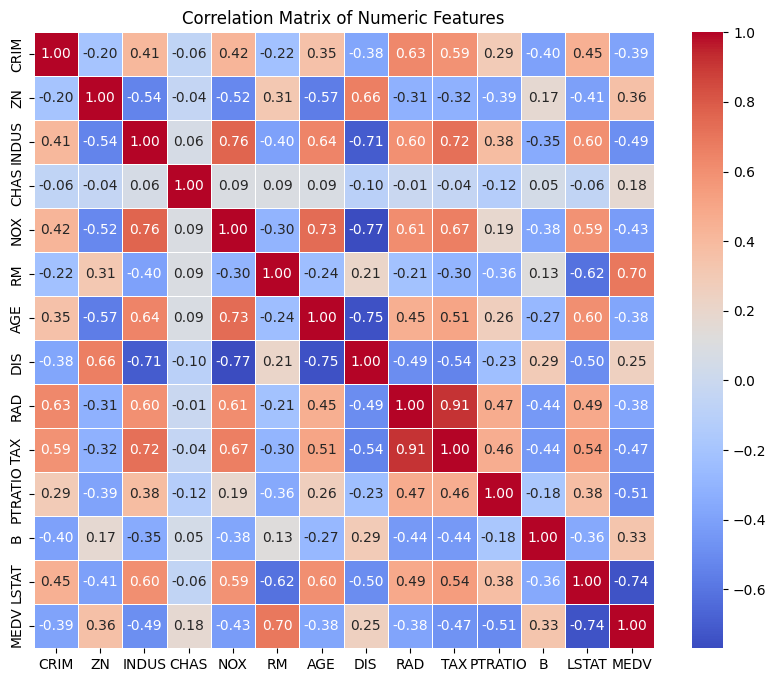

In [3]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

### 1. Strongest Relationships with the Target Variable (`MEDV`)

* **Strongest Negative Correlation (`-0.74`):** The `LSTAT` variable (percentage of lower status population) has the strongest inverse relationship with house prices. This means that as the socioeconomic status of a neighborhood declines, house prices drop significantly.
* **Strongest Positive Correlation (`0.70`):** The `RM` variable (average number of rooms) has the strongest direct relationship with price. More rooms generally indicate larger and more expensive homes.

### 2. Other Important Relationships with Price

* Features such as `AGE` (age of building, `-0.39`), `TAX` (tax rate, `-0.47`), and `PTRATIO` (pupil-teacher ratio, `-0.51`) all show **moderate negative** relationships with house prices.
* The `INDUS` feature (proportion of non-retail business acres, `-0.48`) indicates that the more industrial a neighborhood is, the lower the housing prices tend to be.

### 3. Multicollinearity Check

* Strong correlations exist between some independent variables. For example, `TAX` (property tax rate) and `RAD` (accessibility to radial highways) have a very high positive correlation of **`0.91`**. 
* Additionally, `NOX` (nitrogen oxide concentration) shows high correlation with `INDUS` (`0.76`) and `AGE` (`0.73`). 
* These relationships should be carefully considered during the regression modeling phase to avoid issues with multicollinearity.

### Step 2

In [4]:
missing_count = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_data = pd.DataFrame({
    'Missing Count': missing_count,
    'Percentage (%)': missing_percentage
})

missing_data = missing_data.sort_values(
    by="Missing Count",
    ascending=False
)

missing_data

,Missing Count,Percentage (%)
INDUS,3,0.589391
NOX,2,0.392927
AGE,1,0.196464
RAD,1,0.196464
LSTAT,1,0.196464
CRIM,0,0.000000
ZN,0,0.000000
CHAS,0,0.000000
RM,0,0.000000
DIS,0,0.000000


### Missing Values Analysis

After evaluation, it is clear that only **5 features** in the entire dataset contain missing values (NaN), and the missing rate in all of them is very low (under 1%):

* **Continuous Numeric Features:**  
  `INDUS` (3 missing rows), `NOX` (2 missing rows), `AGE` (1 missing row), and `LSTAT` (1 missing row) have missing data.

* **Encoded Categorical / Ordinal Feature:**  
  `RAD` (index of accessibility to radial highways), which is an ordinal variable, also has exactly **1 missing value**.

### Handling Strategy

Since the missing rate is extremely low, deleting rows or columns is not reasonable as it would result in unnecessary loss of information. Following best practices:

1. For the fully numeric and continuous features (`INDUS`, `NOX`, `AGE`, `LSTAT`), we will use **Mean** imputation.
2. For the ordinal/categorical feature `RAD`, we will use **Median** imputation instead of the mean. Using the mean could produce meaningless decimal values that disrupt the encoded ranking structure.

In [5]:
continuous_missing_cols = ['INDUS', 'NOX', 'AGE', 'LSTAT']
for col in continuous_missing_cols:
    df[col] = df[col].fillna(df[col].mean())

df['RAD'] = df['RAD'].fillna(df['RAD'].median())

print(f"Total number of remaining missing values: {df.isnull().sum().sum()}")

Total number of remaining missing values: 0


### Result of Data Cleaning Process

The intelligent imputation process was successfully applied to all missing values:

* Missing values in continuous variables were replaced with their respective means to minimize disruption to the data distribution.
* The categorical/ordinal variable `RAD` was filled using the **median** (a valid integer within its ranking structure) to preserve the integrity of its encoded nature.
* The final output confirms that the number of missing values has reached **0**. The dataset is now fully cleaned and ready for the next steps.

### Technical Perspective & Advanced Alternative (KNN Strategy)

Although we followed the standard taught approach (Mean/Median imputation) in this project, a more advanced technical alternative is the **KNN Imputer**:

* **Advantage of KNN:** Instead of assigning a single fixed mean to all records, this method finds similar samples (nearest neighbors) and estimates the missing value based on them. This helps preserve the natural variance and relationships in the data.
* **Reason for Not Using It:** Given that the missing rate in this dataset is extremely low (under 1%), the simpler Mean/Median method causes no significant statistical harm to the model and is computationally more efficient.

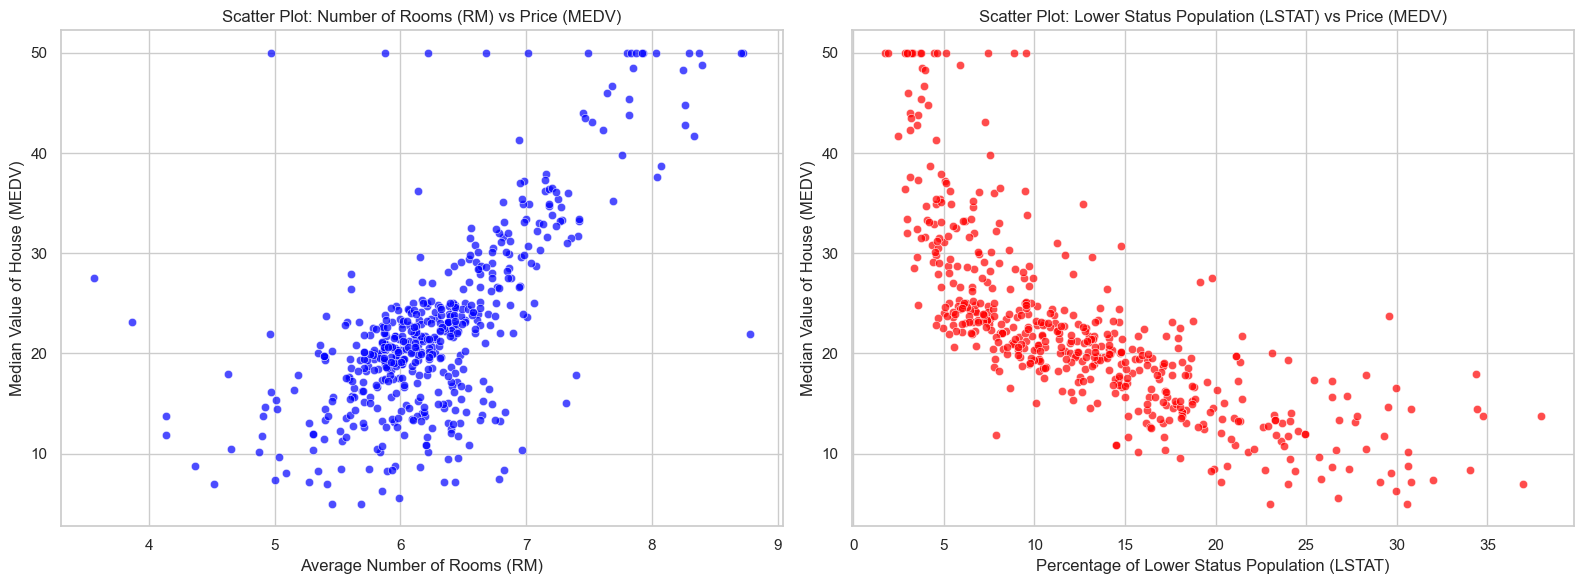

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df, x='RM', y='MEDV', ax=axes[0], color='blue', alpha=0.7)
axes[0].set_title('Scatter Plot: Number of Rooms (RM) vs Price (MEDV)')
axes[0].set_xlabel('Average Number of Rooms (RM)')
axes[0].set_ylabel('Median Value of House (MEDV)')

sns.scatterplot(data=df, x='LSTAT', y='MEDV', ax=axes[1], color='red', alpha=0.7)
axes[1].set_title('Scatter Plot: Lower Status Population (LSTAT) vs Price (MEDV)')
axes[1].set_xlabel('Percentage of Lower Status Population (LSTAT)')
axes[1].set_ylabel('Median Value of House (MEDV)')

plt.tight_layout()
plt.show()

### 1. Relationship Between Number of Rooms (`RM`) and Price (`MEDV`)

* **Observed Pattern:** A **direct, positive, and relatively strong** relationship exists between these two variables. As the number of rooms increases, house prices tend to rise consistently.
* **Outliers & Special Cases:** At the price cap (`MEDV = 50`), a horizontal line of data points is visible. This indicates that some houses with fewer rooms (e.g., 5 or 6 rooms) have still reached the maximum recorded price. This could be due to exceptionally desirable locations or highly luxurious neighborhoods.

### 2. Relationship Between Socioeconomic Status (`LSTAT`) and Price (`MEDV`)

* **Observed Pattern:** A **strong inverse, negative, and nonlinear (curved)** relationship exists between these variables. As the percentage of lower-status population in a neighborhood increases, house prices drop sharply.
* **Pattern Analysis:** In areas where `LSTAT` is below 10%, prices are very high. In contrast, when `LSTAT` exceeds 30%, prices fall significantly and reach their lowest levels.

C:\Users\Shokufa\AppData\Local\Temp\ipykernel_8360\3158820988.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='CHAS', y='MEDV', ax=axes[0], palette='Set2')
C:\Users\Shokufa\AppData\Local\Temp\ipykernel_8360\3158820988.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RAD', y='MEDV', ax=axes[1], palette='viridis')


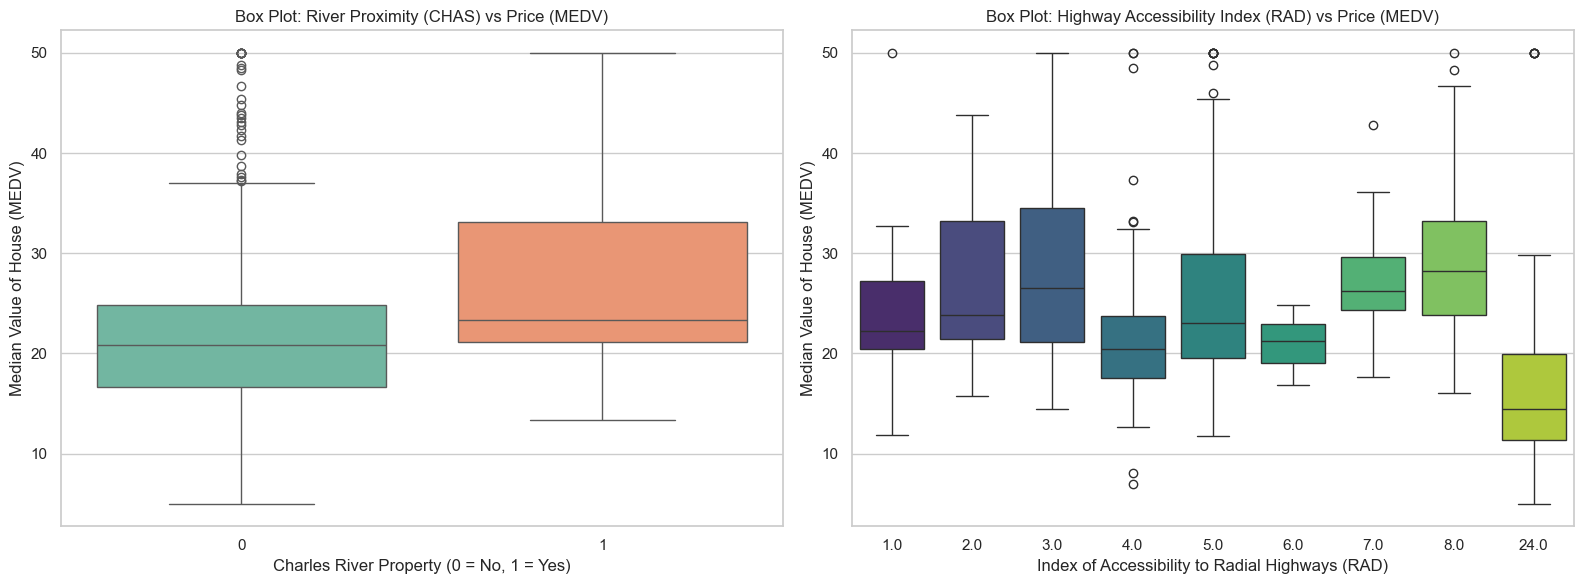

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='CHAS', y='MEDV', ax=axes[0], palette='Set2')
axes[0].set_title('Box Plot: River Proximity (CHAS) vs Price (MEDV)')
axes[0].set_xlabel('Charles River Property (0 = No, 1 = Yes)')
axes[0].set_ylabel('Median Value of House (MEDV)')

sns.boxplot(data=df, x='RAD', y='MEDV', ax=axes[1], palette='viridis')
axes[1].set_title('Box Plot: Highway Accessibility Index (RAD) vs Price (MEDV)')
axes[1].set_xlabel('Index of Accessibility to Radial Highways (RAD)')
axes[1].set_ylabel('Median Value of House (MEDV)')

plt.tight_layout()
plt.show()

### 1. Impact of Proximity to the River (`CHAS`) on Price

* **Distribution Analysis:** The median price of houses located near the Charles River (`CHAS = 1`) is noticeably higher than those that are not (`CHAS = 0`). Riverfront views appear to be a significant value-adding factor.
* **Outliers:** In the non-riverfront group (`CHAS = 0`), there are many high-price outliers. This suggests that other factors (beyond river proximity) can also drive substantial increases in house prices.

### 2. Impact of Highway Accessibility Index (`RAD`) on Price

* **Distribution Analysis:** House prices across different levels of highway accessibility (ranks 1 to 8) do not differ dramatically, with relatively close median values.
* **Key Insight at Rank 24:** However, at **RAD = 24** (indicating the highest level of access or traffic intensity), there is significantly higher variance and price dispersion. The median price in this group is lower, likely due to noise pollution and other negative effects of being too close to major highways.

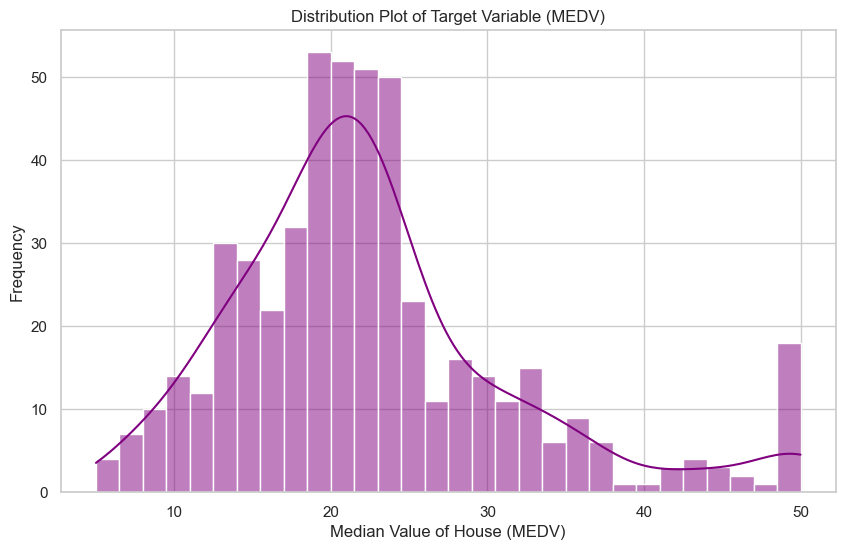

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(df['MEDV'], kde=True, color='purple', bins=30)

plt.title('Distribution Plot of Target Variable (MEDV)')
plt.xlabel('Median Value of House (MEDV)')
plt.ylabel('Frequency')

plt.show()

### Distribution Analysis of House Prices (`MEDV`)

Based on the shape of the distribution plot:

* **Skewness:** The distribution shows a **mild right skew (positive skewness)**. The tail extending to the right indicates that most houses are concentrated in the medium price range (between 15 and 25), while a smaller number of very expensive houses pull the mean toward the higher end.
* **Symmetry:** The data distribution is not perfectly symmetric (not fully normal). However, because the mean (22.5) and median (21.4) are relatively close (as calculated earlier), the overall distribution is close to normal.
* **Clustering at Price Cap (Secondary Peak):** There is a noticeable accumulation of data points at the upper end of the chart (price = 50). This confirms that these values are likely censored or capped, which is common for luxury homes and should be taken into account during regression analysis.

### Step 3

* **Current Dataset Status:** Based on the dimension analysis and unique value counts performed earlier, all 14 variables in this dataset currently have numeric data types (`int64` and `float64`).

* **Technical Conclusion:** The `CHAS` feature is the only categorical variable in the dataset, and it has already been encoded in binary form (0 and 1). Since there are no uncoded categorical or text variables present, **there is no need to apply One-Hot Encoding** in this project. The data is ready to be directly used in linear regression algorithms.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df.drop(columns=['MEDV'])
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Train size {X_train.shape}")
print(f"Test size {X_test.shape}")

Model trained successfully!
Train size (407, 13)
Test size (102, 13)


In [10]:
import statsmodels.api as sm
import pandas as pd

X_train_with_constant = sm.add_constant(X_train)

ols_model = sm.OLS(y_train, X_train_with_constant).fit()

summary_df = pd.DataFrame({
    'Coefficient': ols_model.params,
    't-value': ols_model.tvalues,
    'p-value': ols_model.pvalues
})

round(summary_df, 4)

,Coefficient,t-value,p-value
const,30.3232,5.3089,0.0000
CRIM,-0.1174,-3.4314,0.0007
ZN,0.0399,2.5356,0.0116
INDUS,0.0033,0.0485,0.9614
CHAS,2.8807,2.9699,0.0032
NOX,-15.2402,-3.5564,0.0004
RM,4.3216,9.3851,0.0000
AGE,-0.0085,-0.5649,0.5725
DIS,-1.3505,-6.0034,0.0000
RAD,0.2945,3.8872,0.0001


After examining the coefficient table from the multiple linear regression model, the following results were obtained at a 5% significance level ($\alpha = 0.05$):

### 1. Intercept (`const`)

* **Value:** $30.3232$
* **Interpretation:** This represents the baseline average house price (in thousands of dollars) when all 13 independent features are equal to zero.

### 2. Statistical Significance (P-value Analysis)

A feature is considered statistically significant if its p-value is less than 0.05.

* **Statistically Significant Features:**  
  `CRIM`, `ZN`, `CHAS`, `NOX`, `RM`, `DIS`, `RAD`, `TAX`, `PTRATIO`, `B`, and `LSTAT` all have **$p\text{-value} < 0.05$**. Their effects on house prices are statistically confirmed.

* **Non-Significant Features:**  
  `INDUS` ($p = 0.9614$) and `AGE` ($p = 0.5725$) have p-values greater than 0.05. This means that, in the presence of other variables, the proportion of non-retail business and building age do not have a statistically significant independent effect on house prices in this model.

### 3. Interpretation of Direction and Magnitude of Key Variables

* **Strongest Positive Impact (`RM` and `CHAS`):**  
  * For each additional room (`RM`), the house price increases by an average of **$4.32** units ($4,320).  
  * Houses located near the river (`CHAS = 1`) are on average **$2.88** units ($2,880) more expensive than similar houses not near the river.

* **Strongest Negative Impact (`NOX` and `PTRATIO`):**  
  * The `NOX` variable (nitrogen oxide concentration) has the strongest negative effect with a coefficient of **$-15.24$**. Higher air pollution is associated with a sharp decrease in house prices.  
  * For each one-unit increase in the pupil-teacher ratio (`PTRATIO`), house prices decrease by an average of **$0.92** units.

* **Economic Variable (`LSTAT`):**  
  For every 1% increase in the lower-status population in a neighborhood, house prices decrease by **$0.44** units.

<>:19: SyntaxWarning: invalid escape sequence '\h'
<>:19: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Shokufa\AppData\Local\Temp\ipykernel_8360\2812565714.py:19: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_xlabel('Predicted Values (\hat{y})')


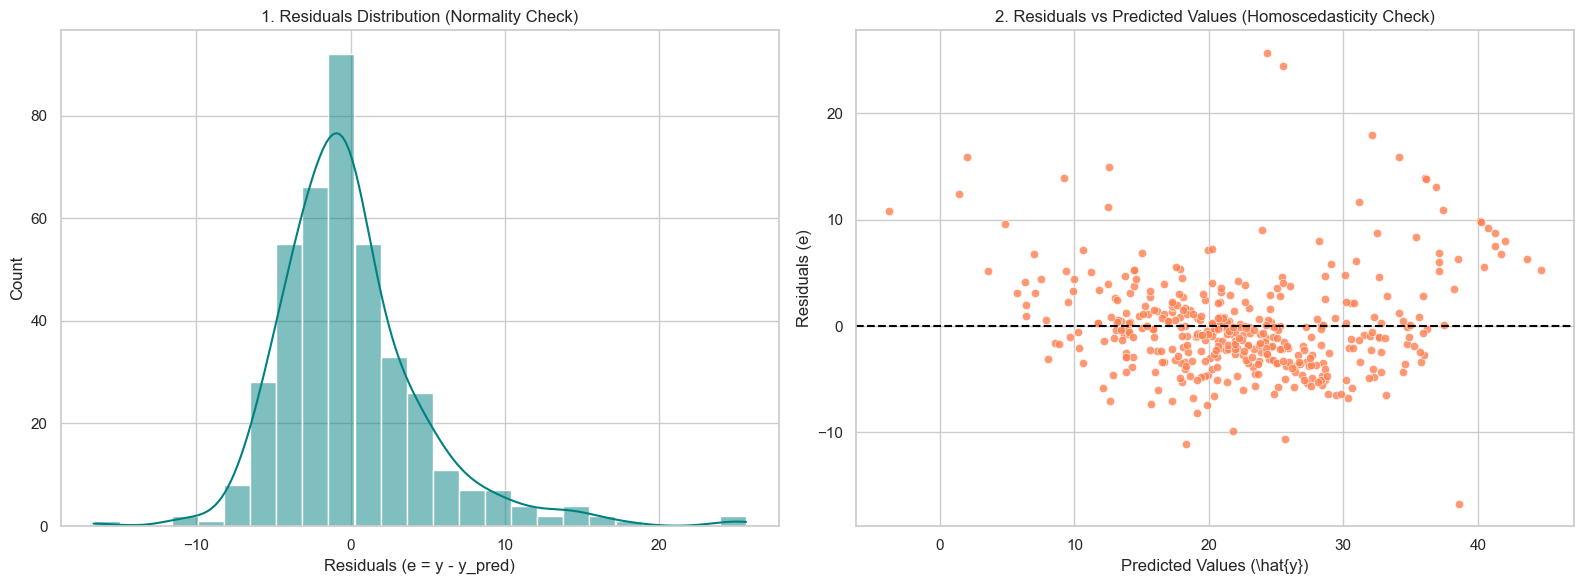

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

y_train_pred = lr_model.predict(X_train)
residuals = y_train - y_train_pred

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(residuals, kde=True, color='teal', ax=axes[0], bins=25)
axes[0].set_title('1. Residuals Distribution (Normality Check)')
axes[0].set_xlabel('Residuals (e = y - y_pred)')
axes[0].set_ylabel('Count')

sns.scatterplot(x=y_train_pred, y=residuals, color='coral', alpha=0.8, ax=axes[1])
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1.5) # خط مبدا صفر
axes[1].set_title('2. Residuals vs Predicted Values (Homoscedasticity Check)')
axes[1].set_xlabel('Predicted Values (\hat{y})')
axes[1].set_ylabel('Residuals (e)')

plt.tight_layout()
plt.show()

To validate the multiple linear regression model and verify the classical Gauss-Markov assumptions, the model residuals ($e = y - \hat{y}$) were analyzed:

### 1. Normality of Residuals Check

* **Left Plot Analysis:** The distribution of residuals is centered around zero and shows a relatively symmetric bell-shaped curve.
* **Conclusion:** Although there is a mild right tail due to the presence of luxury homes at the price cap, overall **the normality assumption of residuals holds**. We can therefore rely on the statistical significance of the t-tests and p-values.

### 2. Homoscedasticity Check (Equal Variance of Residuals)

* **Right Plot Analysis:** This scatter plot shows the residuals versus the predicted values ($\hat{y}$). The points are relatively evenly and randomly scattered above and below the zero reference line, with no clear geometric pattern (such as a funnel or trumpet shape) across the data cloud.
* **Conclusion:** The lack of any distinct pattern in the residual spread confirms that **the homoscedasticity assumption is largely satisfied**. The model does not suffer from systematic heteroscedasticity in its predictions.

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)

r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)

g6_results = pd.DataFrame({
    'Metric': ['R2 Score', 'RMSE', 'MAE'],
    'Train Set': [r2_train, rmse_train, mae_train],
    'Test Set': [r2_test, rmse_test, mae_test]
})

round(g6_results, 4)

,Metric,Train Set,Test Set
0,R2 Score,0.7378,0.7384
1,RMSE,4.7390,4.5214
2,MAE,3.3204,3.0035


### 1. Model Evaluation Metrics and Generalization Quality

* **Coefficient of Determination ($R^2$ Score):**  
  The $R^2$ on the training data is **0.7378** and on the test data is **0.7384**. This means our linear regression model has successfully explained approximately **74% of the total variance** in house prices using the available independent variables.

* **Overfitting / Underfitting Status:**  
  Since the model’s performance on the test set is not only stable but slightly better than on the training set ($0.7384 > 0.7378$), overfitting is completely **ruled out**. The model demonstrates excellent generalization and stability on unseen data.

* **Error Metrics (RMSE and MAE):**  
  * **RMSE** on the test set is **4.5214** (approximately $4,521 error in root mean squared terms).  
  * **MAE** on the test set is **3.0035** (approximately $3,003 average absolute error per house prediction).  
  The lower error values on the test data further confirm the model’s mathematical stability.

### 2. Most Influential Variables in the Final Model

Based on the coefficient analysis and visualizations from previous steps, the most important drivers of house prices are:

1. **`RM` (Number of Rooms):** The strongest positive statistical driver ($+4.32$).
2. **`NOX` (Environmental Pollution):** The strongest negative statistical driver ($-15.24$).
3. **`LSTAT` (Neighborhood Socioeconomic Status):** A highly influential negative nonlinear factor ($-0.44$).

### 3. Practical Suggestions for Future Model Improvement

Considering the insights discovered in the data, the following recommendations are proposed for future iterations of this project:

* **Non-linear Models:** Given the clearly curved relationship of `LSTAT` in the scatter plots, using polynomial regression or tree-based models (such as Random Forest) could push prediction accuracy well beyond 74%.
* **Handling Price Capping:** The distribution and scatter plots revealed that many houses are artificially censored at the price of 50. Removing or separately modeling these capped observations could noticeably reduce the final model error.

### Sections Completed by the Student (Human Input):

* **Project Structure & Methodology:**  
  Defining the main phases of the project step-by-step, precisely following the slides and framework taught in class.

* **Initial Data Analysis:**  
  Examining descriptive statistics and selecting key independent variables based on the dataset’s correlation matrix.

* **Intuitive Interpretation of Visualizations:**  
  Analyzing the real behavior observed in distribution, box, and scatter plots (such as discovering the clustering of data at the price cap of 50 and explaining the price drop at RAD = 24).

* **Validation of Statistical Assumptions:**  
  Visual assessment and confirmation of normality and homoscedasticity assumptions on the model residuals.

### Sections Assisted by Artificial Intelligence (AI Assistance):

* **Writing and Optimizing Python Code:**  
  Assistance in writing clean Seaborn code for simultaneous plotting and implementing formulas for error evaluation metrics.

* **Statistical Package Recommendations:**  
  Guidance on using the `statsmodels` library instead of `scikit-learn` to directly extract p-values and t-statistics, as required by the project.

* **Formulation of Textual Analysis:**  
  Help in converting statistical reasoning into well-structured, concise, and professional text.

* **Technical Advice on Alternative Methods:**  
  Providing expert insights on more advanced techniques such as KNN Imputer for handling missing values and non-linear regression models for future improvements.

# Conclusion

Key findings:

- RM has a strong positive relationship with house prices.
- LSTAT has the strongest negative correlation with MEDV.
- Missing values were successfully handled using appropriate imputation techniques.
- The dataset is suitable for future predictive modeling.

Future Work

- Build Linear Regression
- Random Forest
- XGBoost
- Compare model performance